#  Learning Style: Myth or Reality?
### A Multi-Task Predictive Audit of Student Performance

**Daset:** [Student Performance and Learning Behavior Dataset (Kaggle, Adil Shamim, 2025)](https://www.kaggle.com/datasets/adilshamim8/student-performance-and-learning-style)

**Records:** 14,003 student records | 16 attributes

## 1. Overview and Motivation

Educational institutions worldwide have embraced the concept of learning styles — the idea that students learn better when instruction is matched to their preferred mode of information processing, whether visual, auditory, read/write, or kinaesthetic. Software platforms, curriculum designers, and teachers routinely classify students by learning style and tailor content accordingly. Yet decades of educational psychology research have found little controlled evidence that this matching actually improves outcomes.

This project invites you to test that question empirically. Using a real dataset of 14,003 students, you will build a rigorous machine learning pipeline to predict two academic outcomes simultaneously: a student's Exam Score (regression) and their Final Grade category (classification). You will then use advanced interpretability tools to determine whether the LearningStyle feature contributes genuine predictive power, or whether it is simply a relabelling of behavioural variables already in the dataset — a form of circular reasoning embedded in the data itself.

The strongest groups will produce findings that go beyond the course: the existing published analysis of this dataset does not include ablation experiments or SHAP-based interpretability. There is original scientific contribution available here for any group willing to pursue it rigorously.

## 2. Research Questions

Your project must provide an evidence-based answer to each of the following questions. The answers must emerge from your experimental results, not from prior assumptions or literature alone.

1. RQ1. Can a machine learning model predict a student's Exam Score and Final Grade from their behavioural and motivational profile with meaningful accuracy, and which model family performs best?
2. RQ2. Does the LearningStyle label add statistically meaningful predictive power once all other features are available, as measured by an ablation experiment?
3. RQ3. Are the LearningStyle labels in the dataset independently derived, or do they largely recapitulate structure already visible in the behavioural features — and how do you know?
4. RQ4. If a school used your best model to intervene on at-risk students, what are the realistic harms, who bears them, and how should the model be constrained?


## 3. Dataset

The dataset was created by merging two publicly available Kaggle datasets and contains 14,003 anonymised student records with no personally identifiable information. The 16 attributes span four domains.

**Study Behaviours and Engagement**

StudyHours (numeric, average hours studied per week), Attendance (numeric, percentage), Extracurricular (binary), AssignmentCompletion (numeric, percentage), OnlineCourses (numeric, count), Discussions (binary or numeric participation indicator).

**Resources and Learning Environment**

Resources (categorical or ordinal, access to learning resources), Internet (binary), EduTech (binary, use of educational technology tools).

**Motivation and Psychological Factors**

Motivation (ordinal or numeric), StressLevel (ordinal or numeric).

**Demographics and Classification**

Gender (categorical), Age (numeric, 18 to 30 years), LearningStyle (categorical: Visual / Auditory / Read-Write / Kinaesthetic — the variable under audit).

**Performance Targets**

ExamScore (numeric, primary regression target) and FinalGrade (categorical, primary classification target). Both must be used. You may not use one as a feature while predicting the other.

## 4. Step-by-Step Work Plan

The following steps are mandatory unless explicitly marked as stretch goals. Each step produces a concrete artefact (a figure, a table, or a written paragraph) that must appear in your final article. Work through the steps in order: later steps depend on decisions made in earlier ones.

### STEP 1: Data Loading, Audit, and Preprocessing

Understand every column in the dataset before writing a single model line.

In [1]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier, XGBRegressor

In [2]:
line = 60 * '-'

df = pd.read_csv('../data/student_performance.csv')

n_rows, n_cols = df.shape

print(f"O dataset tem {n_rows} linhas e {n_cols} colunas.")
print('\n' + line + '\n')

df.info()

df.head()

O dataset tem 14003 linhas e 16 colunas.

------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [3]:
# Listar todas as colunas
columns = df.columns.to_list()

# Separa os índices para as colunas numéricas e categóricas
numeric_indx = [0, 1, 7, 9, 11, 12]
categorical_indx = [2, 3, 4, 5, 6, 8, 10, 13, 14, 15]

# Listar as colunas numéricas e as categóricas
numeric_cols = [columns[i] for i in numeric_indx]
categorical_cols = [columns[i] for i in categorical_indx]

# Separar o dataframe em numéricas e categórics
df_categorical = df[categorical_cols]
df_numerical = df[numeric_cols]

# Exibir os dados
print(f"Colunas numéricas: \n{numeric_cols}\n")
print(f"Colunas categóricas: \n{categorical_cols[:6]}\n{categorical_cols[6:]}\n")
print("-" * 20)

print(f"\n{df_categorical.apply(pd.Series.value_counts)}")

print("-" * 20)

df_numerical.describe()

Colunas numéricas: 
['StudyHours', 'Attendance', 'Age', 'OnlineCourses', 'AssignmentCompletion', 'ExamScore']

Colunas categóricas: 
['Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'LearningStyle']
['Discussions', 'EduTech', 'StressLevel', 'FinalGrade']

--------------------

   Resources  Extracurricular  Motivation  Internet  Gender  LearningStyle  \
0     2750.0           5683.0      4112.0    1043.0  6274.0           3376   
1     7041.0           8320.0      7098.0   12960.0  7729.0           3580   
2     4212.0              NaN      2793.0       NaN     NaN           3500   
3        NaN              NaN         NaN       NaN     NaN           3547   

   Discussions  EduTech  StressLevel  FinalGrade  
0       5519.0   4074.0       2836.0        3832  
1       8484.0   9929.0       4069.0        3310  
2          NaN      NaN       7098.0        3618  
3          NaN      NaN          NaN        3243  
--------------------


,StudyHours,Attendance,Age,OnlineCourses,AssignmentCompletion,ExamScore
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,23.532172,9.891952,74.502535,70.346926
std,5.890637,11.472181,3.514293,6.112801,14.632177,17.688113
min,5.000000,60.000000,18.000000,0.000000,50.000000,40.000000
25%,16.000000,70.000000,20.000000,5.000000,62.000000,55.000000
50%,20.000000,80.000000,24.000000,10.000000,74.000000,70.000000
75%,24.000000,90.000000,27.000000,15.000000,87.000000,86.000000
max,44.000000,100.000000,29.000000,20.000000,100.000000,100.000000


**Análise univariada**

Para compreendermos como estão distribuídos os valores pelos atributos fizemos os gráficos a seguir. Na primeira célula estão os gráficos de barra para os atributos categóricos e a quantidade de cada categoria. Na segunda célula, estão os histogramas para visualização das distribuições dos valores dos atributos numéricos (discretos e contínuos).

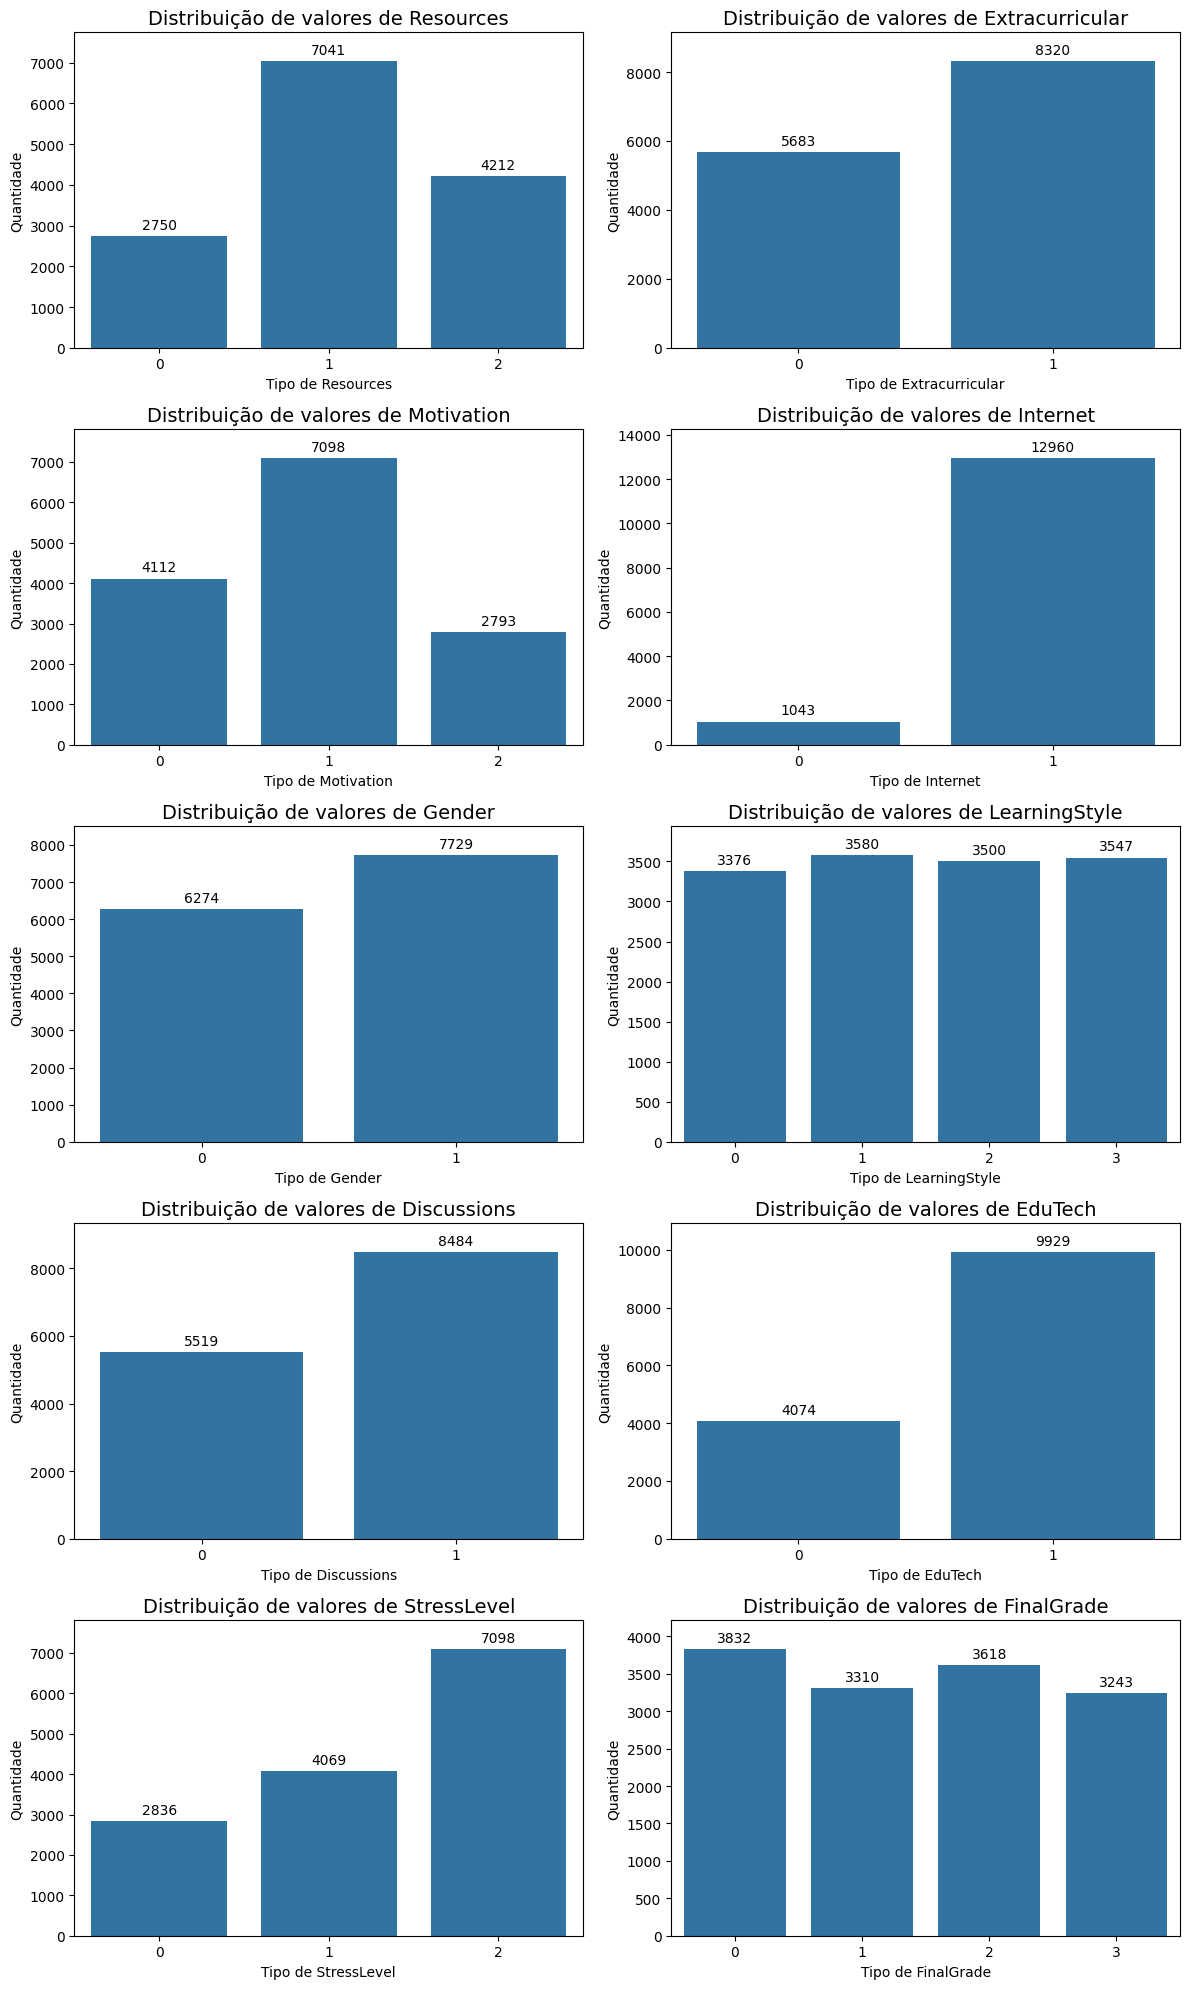

In [23]:
# Atributos categóricos
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))
axes_flat = axes.flatten()

for i, col in enumerate(categorical_cols):
    df_temp = df.groupby(col)[col].count()
    cat_plot = sns.barplot(data=df_temp, ax=axes_flat[i])

    for container in cat_plot.containers:
        axes_flat[i].bar_label(container, padding=3, fontsize=10)

    axes_flat[i].set_title(f'Distribuição de valores de {col}', fontsize=14)
    axes_flat[i].set_xlabel(f'Tipo de {col}')
    axes_flat[i].set_ylabel('Quantidade')
    axes_flat[i].margins(y=0.1)

plt.tight_layout()
plt.show()

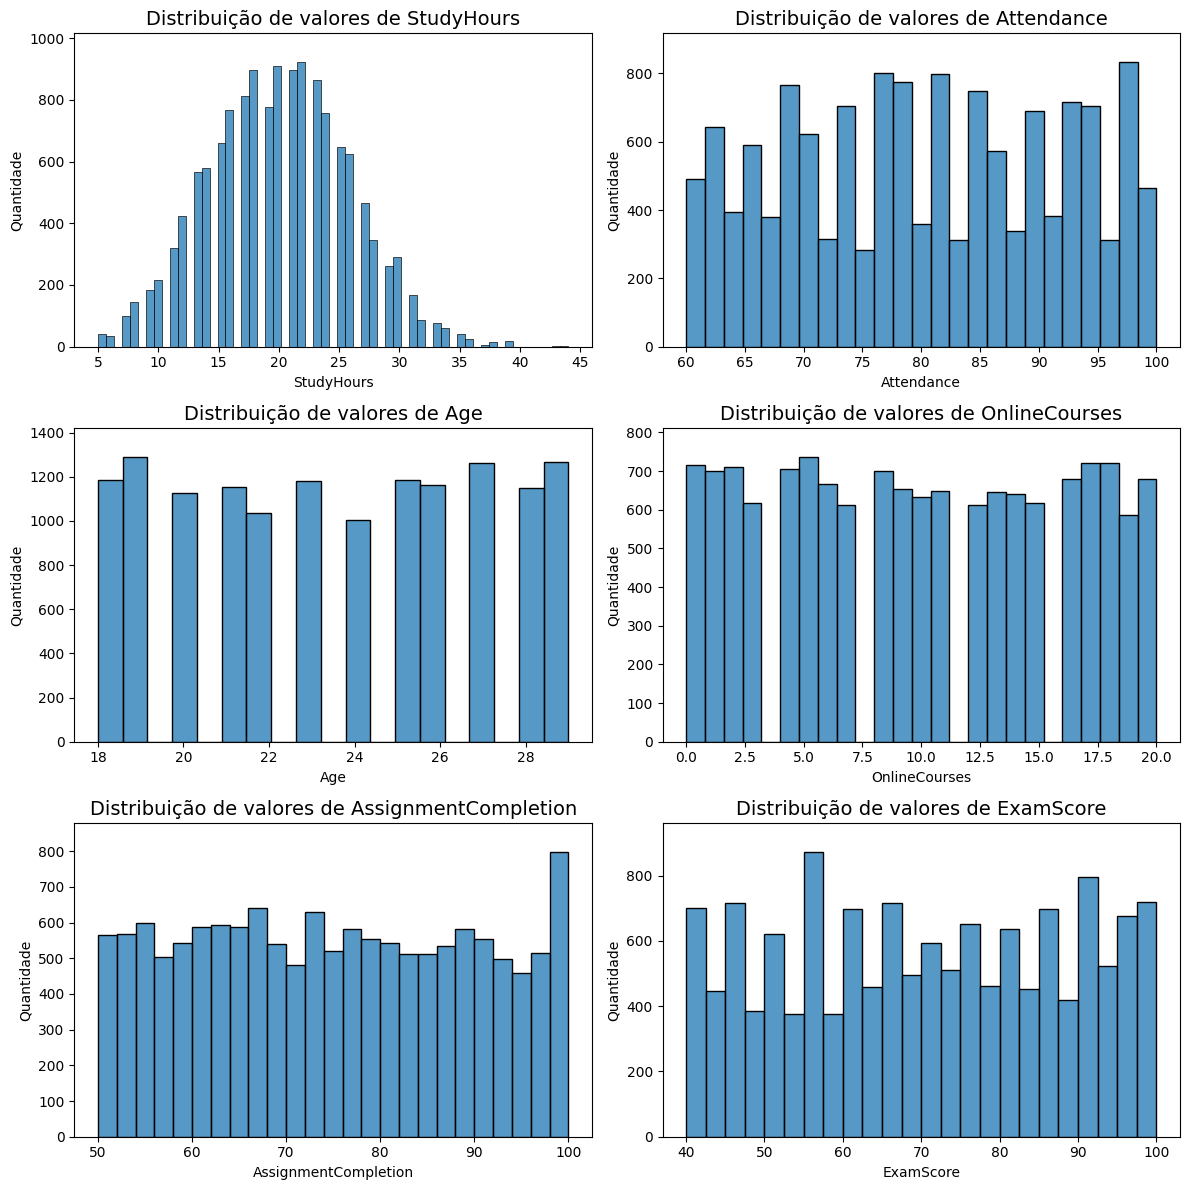

In [29]:
# Atributos numéricos
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    num_plot = sns.histplot(data=df, x=col, ax=axes_flat[i])

    for container in cat_plot.containers:
        axes_flat[i].bar_label(container, padding=3, fontsize=10)

    axes_flat[i].set_title(f'Distribuição de valores de {col}', fontsize=14)
    axes_flat[i].set_xlabel(f'{col}')
    axes_flat[i].set_ylabel('Quantidade')
    axes_flat[i].margins(y=0.1)

plt.tight_layout()
plt.show()

**Valores Ausentes**

Como não havia valores ausentes no dataset não foi preciso criar um heatmat e nem ter uma estratégia de imputação.

In [4]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
})

if summary['missing_count'].sum() == 0:
    print("Não há valores ausentes no dataset.")
else:
    print("Valores ausentes por coluna:")
    print(summary[summary['missing_count'] > 0])

Não há valores ausentes no dataset.


**Valores duplicados**

Consideramos que as 1.534 linhas duplicadas (10,95%) são dados coincidentes e, portanto, resolvemos não apagar.

In [6]:
duplicates = df[df.duplicated(keep=False)]
n_duplicates = df.duplicated().sum()
duplicates_per = n_duplicates/n_rows * 100

print(f"Número de linhas duplicadas: {n_duplicates} ({duplicates_per:.2f}%)")

# print(duplicates.sort_values(by=list(df.columns)))

Número de linhas duplicadas: 1534 (10.95%)


**Correlação das características**

Não há correlação significativa entre nenhuma das características numéricas. Ainda assim os três pares com a maior correlação absoluta foram:
1. Attendance e Age: -0.044
2. StudyHours e Attendance: 0.028
3. AssignmentCompletion	e ExamScore: 0.025

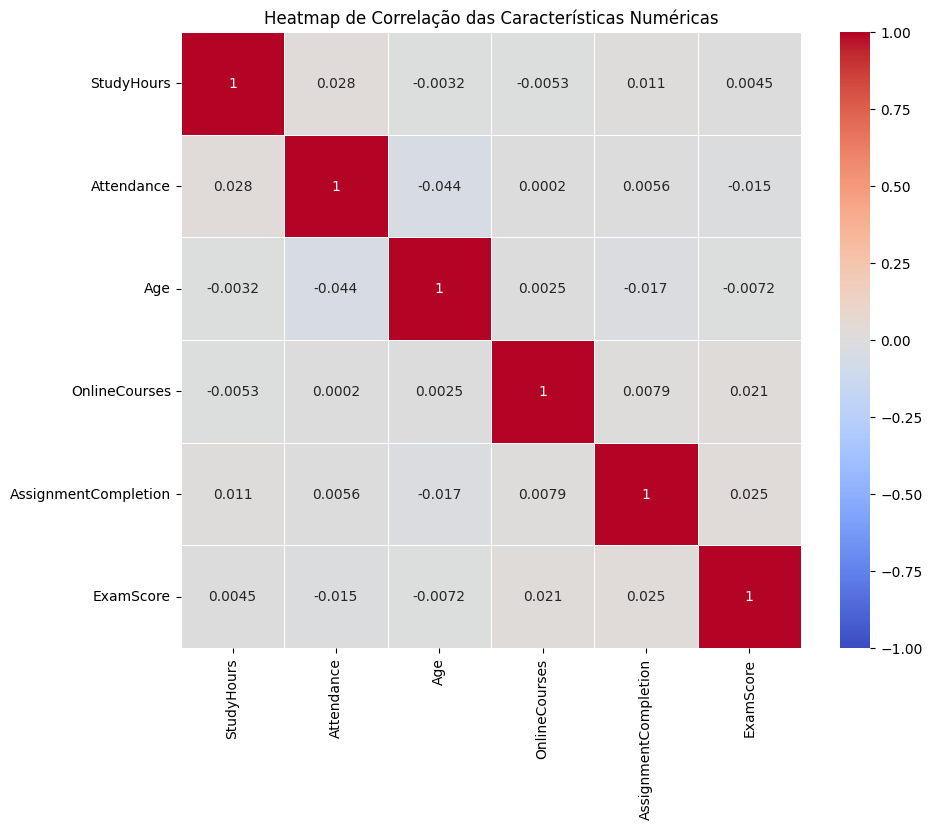

In [7]:
# Calcular a matriz de correlação
# O método .corr() calcula por padrão a correlação de Pearson
corr_matrix = df_numerical.corr()

# Criar o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,      # Mostra os valores dentro dos quadrados
            cmap='coolwarm', # Escala de cores (azul frio para negativo, vermelho quente para positivo)
            center=0,
            fmt=".2g",       # Formatação dos números
            vmin=-1, vmax=1,
            linewidths=0.5)  # Pequeno espaço entre os quadrados

plt.title('Heatmap de Correlação das Características Numéricas')
plt.show()

### Key Features

- **Study behaviors & engagement →** StudyHours, Attendance, Extracurricular, AssignmentCompletion, OnlineCourses, Discussions
- **Resources & environment →** Resources, Internet, EduTech
- **Motivation & psychology →** Motivation, StressLevel
- **Demographics →** Gender, Age (18–30 years)
- **Learning preference →** LearningStyle
- **Performance indicators →** ExamScore, FinalGrade

### Column Descriptions

- **StudyHours** – Number of study hours per week. [Numeric]
- **Attendance** – Percentage of classes attended. [Numeric]
- **Resources** – Availability level and use of academic resources (Low, Medium, High). [Categorical]
- **Extracurricular** – Participation in extracurricular activities (Y/N). [Categorical]
- **Motivation** – Self-reported motivation level (Low, Medium, High). [Categorical]
- **Internet** – Access to the internet for study purposes (Y/N). [Categorical]
- **Gender** – Student’s gender (Male, Female). [Categorical]
- **Age** – Age of student (18–30 years). [Numeric]
- **LearningStyle** – Preferred learning style (Visual, Auditory, Kinesthetic, Reading/Writing). [Categorical]
- **OnlineCourses** – Number of participations in online courses. [Numeric]
- **Discussions** – Engagement in study group discussions or forums. [Categorical]
- **AssignmentCompletion** – Rate of completing assignments on time (numeric scale). [Numeric]
- **ExamScore** – Score obtained in the main exam. [Numeric]
- **EduTech** – Usage of educational technology tools/platforms. [Categorical]
- **StressLevel** – Self-reported stress level (Low, Medium, High). [Categorical]
- **FinalGrade** – Final course grade (target variable for prediction - A, B, C, D). [Categorical]

### STEP 2: Exploratory Data Analysis

Build intuition about what actually drives performance before modelling.

**Plot distributions of ExamScore and FinalGrade.**

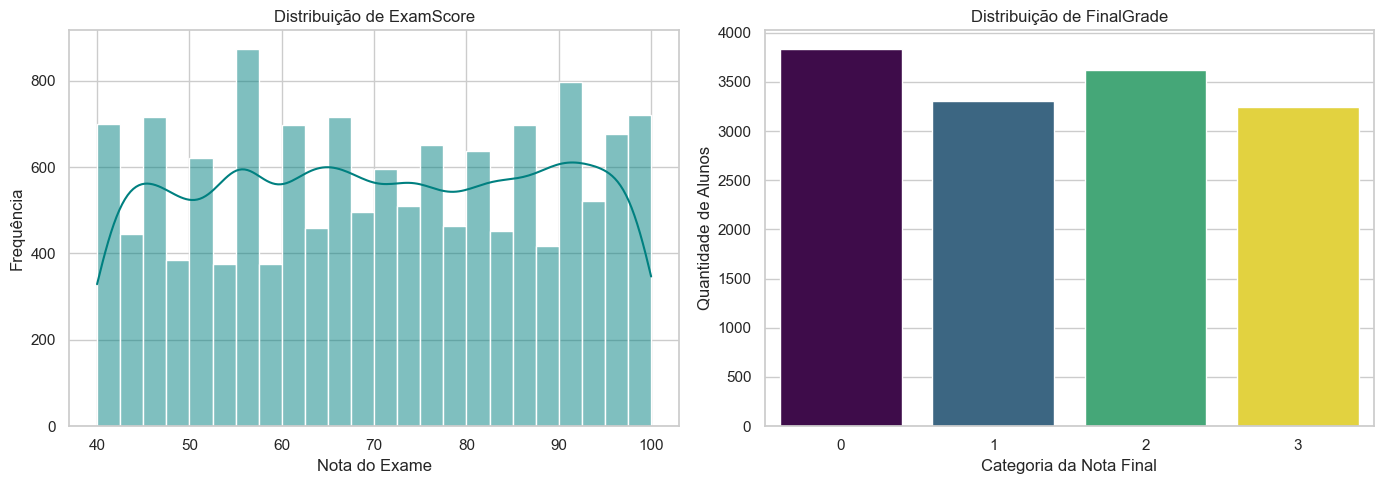

In [8]:
# Definindo o estilo visual
sns.set_theme(style="whitegrid")

# Criando uma figura com 2 subplots (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribuição de ExamScore (Histograma + KDE)
sns.histplot(df['ExamScore'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribuição de ExamScore')
axes[0].set_xlabel('Nota do Exame')
axes[0].set_ylabel('Frequência')

# 2. Distribuição de FinalGrade (Gráfico de Contagem)
# Usamos countplot porque FinalGrade tem categorias fixas (0, 1, 2, 3)
sns.countplot(data=df, x='FinalGrade', ax=axes[1], palette='viridis', hue='FinalGrade', legend=False)
axes[1].set_title('Distribuição de FinalGrade')
axes[1].set_xlabel('Categoria da Nota Final')
axes[1].set_ylabel('Quantidade de Alunos')

# Ajusta o layout para não sobrepor os títulos
plt.tight_layout()
plt.show()

Como as duas variáveis têm naturezas diferentes, usamos um histograma com KDE (linha de densidade) para o score e um gráfico de contagem para a nota final.

1. **`ExamScore` (Histplot):** Como essa variável tem uma amplitude maior (0 a 100), o histograma agrupa os valores em "bins" (caixas) para mostrar a forma da distribuição. O parâmetro `kde=True` desenha uma linha suave que ajuda a identificar se a distribuição é Normal, Assimétrica ou se possui Picos Duplos.
2. **`FinalGrade` (Countplot):** `FinalGrade` possui apenas os valores `[0, 1, 2, 3]`, tratamos ela como uma variável categórica ordinal. O countplot é mais preciso aqui pois mostra a contagem exata de cada nível, permitindo ver rapidamente qual é a nota mais comum entre os alunos.

**Plot ExamScore against StudyHours, Attendance, and Motivation using scatter plots with a regression line.**

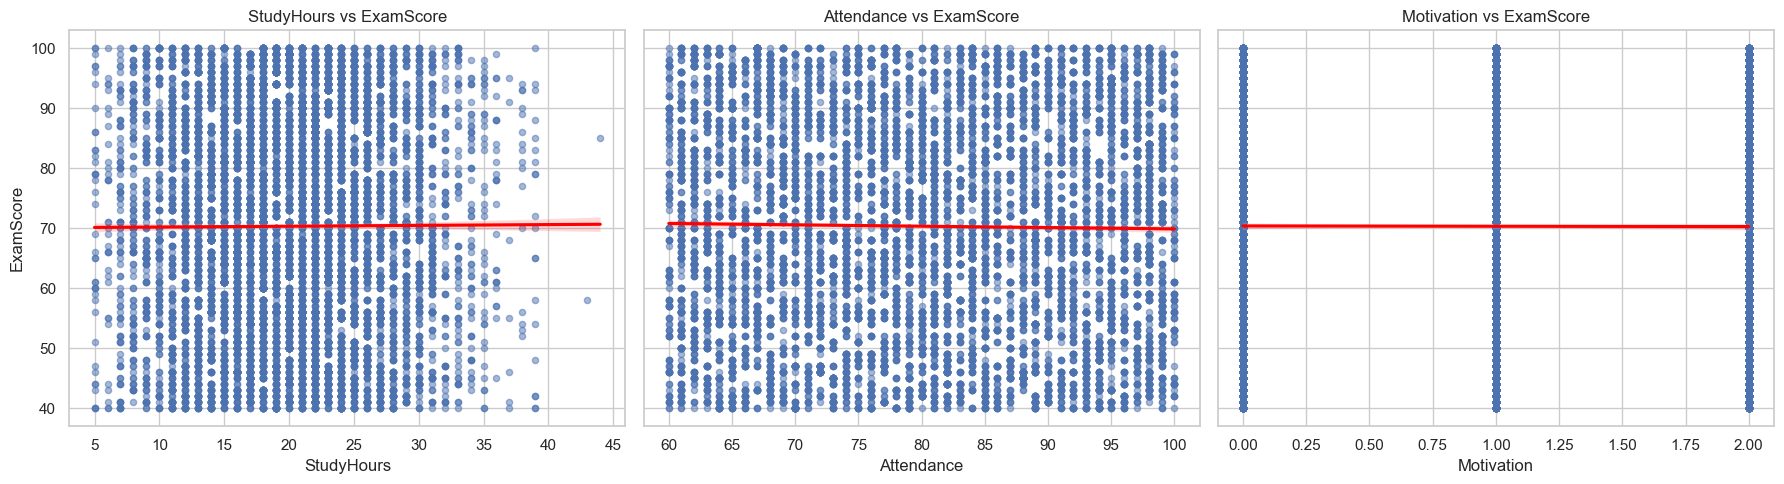

In [9]:
# 1. Definir as variáveis preditoras
predict_features = ['StudyHours', 'Attendance', 'Motivation']
target = 'ExamScore'

# 2. Configurar a figura (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 3. Loop para criar cada gráfico
for i, col in enumerate(predict_features):
    sns.regplot(data=df, x=col, y=target, ax=axes[i], 
                scatter_kws={'alpha':0.5, 's':20}, # Transparência e tamanho dos pontos
                line_kws={'color':'red'})          # Cor da linha de regressão
    
    axes[i].set_title(f'{col} vs {target}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target if i == 0 else "") # Só coloca o nome no eixo Y do primeiro

plt.tight_layout()
plt.show()

**Conclusão:**

Não existe uma relação linear clara entre as variáveis e o `ExamScore`.

Em todos os gráficos (StudyHours, Attendance e Motivation), a linha vermelha está quase perfeitamente horizontal (inclinação próxima de zero). Isso significa que o valor de ExamScore não aumenta nem diminui de forma previsível conforme as outras variáveis mudam, indicando uma correlação nula ou baixíssima.

Os pontos azuis preenchem quase todo o espaço vertical para qualquer valor do eixo X. Isso sugere que estas variáveis, sozinhas, não explicam o desempenho acadêmico neste conjunto de dados específico.

As variáveis StudyHours e Attendance parecem variáveis contínuas (ou com muitos níveis), mas os dados estão tão espalhados que formam uma "nuvem" uniforme. Já Motivation é uma variável categórica (níveis 0, 1 e 2), mas a distribuição das notas está igualmente distribuído para os três níveis de motivação.

**Boxplot of ExamScore grouped by LearningStyle**

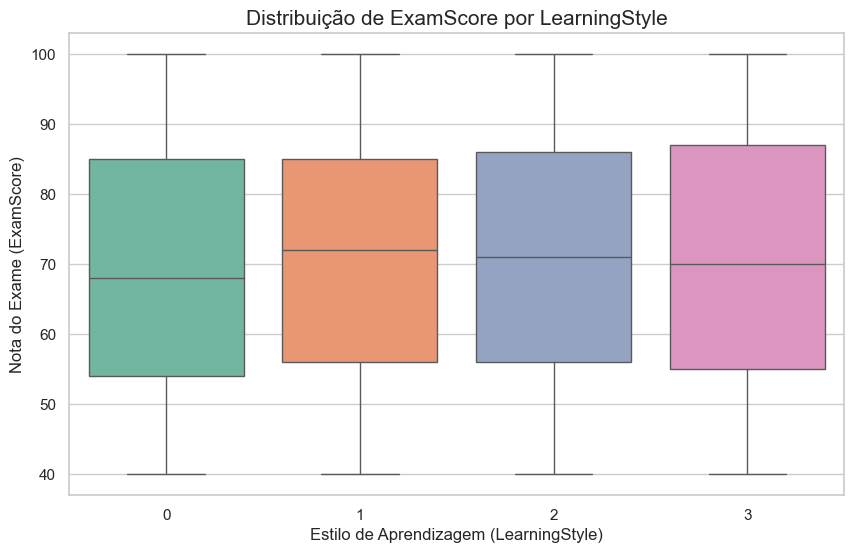

In [10]:
# Configurando o tamanho da imagem
plt.figure(figsize=(10, 6))

# Criando o boxplot
# x: variável categórica (LearningStyle)
# y: variável numérica (ExamScore)
sns.boxplot(
    data=df, x='LearningStyle', y='ExamScore', 
    palette='Set2', hue='LearningStyle', legend=False
)

# Adicionando títulos e rótulos
plt.title('Distribuição de ExamScore por LearningStyle', fontsize=15)
plt.xlabel('Estilo de Aprendizagem (LearningStyle)', fontsize=12)
plt.ylabel('Nota do Exame (ExamScore)', fontsize=12)

# Exibindo o gráfico
plt.show()

**Conclusão:**

As caixas são praticamente iguais, com apenas algumas poucas diferenças marginais entre elas (inclusive nos valores máximos e mínimos), indicando que o `LearningStyle`, praticamente, não afeta a nota final do exame (`ExamScore`).

**Boxplot grouped by Gender & grouped by StressLevel**

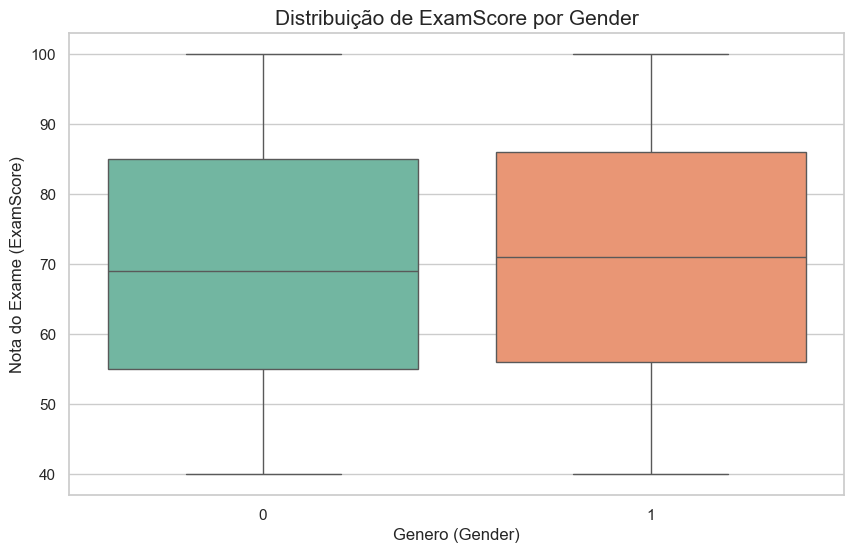

In [11]:
# Configurando o tamanho da imagem
plt.figure(figsize=(10, 6))

# Criando o boxplot
# x: variável categórica (Gender)
# y: variável numérica (ExamScore)
sns.boxplot(
    data=df, x='Gender', y='ExamScore', 
    palette='Set2', hue='Gender', legend=False
)

# Adicionando títulos e rótulos
plt.title('Distribuição de ExamScore por Gender', fontsize=15)
plt.xlabel('Genero (Gender)', fontsize=12)
plt.ylabel('Nota do Exame (ExamScore)', fontsize=12)

# Exibindo o gráfico
plt.show()

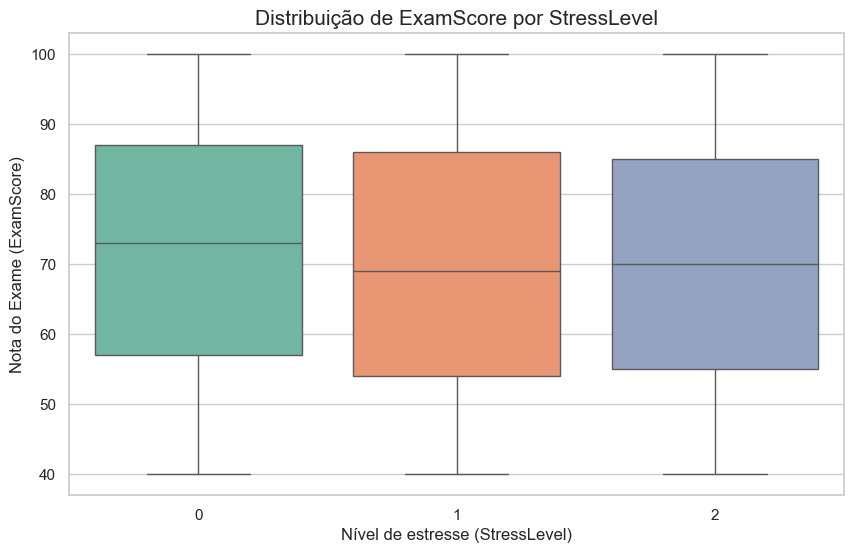

In [12]:
# Configurando o tamanho da imagem
plt.figure(figsize=(10, 6))

# Criando o boxplot
# x: variável categórica (StressLevel)
# y: variável numérica (ExamScore)
sns.boxplot(
    data=df, x='StressLevel', y='ExamScore', 
    palette='Set2', hue='StressLevel', legend=False
)

# Adicionando títulos e rótulos
plt.title('Distribuição de ExamScore por StressLevel', fontsize=15)
plt.xlabel('Nível de estresse (StressLevel)', fontsize=12)
plt.ylabel('Nota do Exame (ExamScore)', fontsize=12)

# Exibindo o gráfico
plt.show()

**Conclusão:**

Similar ao que indica o `LearningStyle`, tanto o `Gender`, quanto o `StressLevel` tem suas caixas muito parecidas entre si, praticamente, não afetando a nota final do exame (`ExamScore`).

#### Hipótese Final

A análise exploratória dos dados revela uma independência quase absoluta entre o desempenho acadêmico (`ExamScore`) e as variáveis preditoras analisadas. Os gráficos de dispersão para `StudyHours` e `Attendance` apresentam uma distribuição em "nuvem" uniforme, com linhas de regressão horizontais que indicam uma correlação linear nula. Da mesma forma, os boxplots para `LearningStyle`, `Gender` e `StressLevel` exibem medianas e intervalos interquartis quase idênticos. 

O que mais surpreende nestes resultados é a ausência do impacto esperado de fatores tradicionalmente decisivos, como o tempo de estudo e a frequência escolar, sugerindo que, neste conjunto de dados, o sucesso no exame não é determinado por comportamentos isolados ou características demográficas e psicológicas superficiais.

Dessa forma, entramos na fase de modelagem com a hipótese de que o `LearningStyle` não possui poder preditivo individual significativo sobre a nota final. A uniformidade das distribuições entre os diferentes estilos de aprendizagem indica que nenhum método (seja visual, auditivo ou prático) oferece vantagem estatística. 

Nossa expectativa para o modelo é que ele apresente um baixo coeficiente de determinação ($R^2$), a menos que existam interações complexas e não lineares entre as variáveis que ainda não foram capturadas pelas visualizações univariadas e bivariadas.

### STEP 3: Baseline Models

Establish honest benchmarks that your advanced models must beat meaningfully.

#### For classification (FinalGrade):

Train a Logistic Regression baseline with default hyperparameters inside a Pipeline. Report Accuracy, weighted F1, and AUC-ROC on the held-out test set (20% split, stratified).

In [13]:
# 1. Separação de Features (X) e Target (y)
X = df.drop(columns=['FinalGrade', 'ExamScore']) 
y = df['FinalGrade']

# 2. Definição das colunas por tipo
numeric_features = ['StudyHours', 'Attendance', 'Age', 'OnlineCourses', 'AssignmentCompletion']
categorical_features = ['Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'LearningStyle', 'Discussions', 'EduTech', 'StressLevel']

# 3. Construção dos Transformers (Imputação e Escalonamento)
# Seguindo a estratégia: mediana para numéricos e moda para categóricos
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # Recomendado para regressão logística
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Moda
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinando os pré-processadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Criação do Pipeline Final com Regressão Logística
# Nota: max_iter aumentado para garantir convergência com hiperparâmetros padrão
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 5. Split dos dados (20% teste, estratificado pelo target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Treinamento
pipeline.fit(X_train, y_train)

# 7. Predições e Avaliação
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test) # Probabilidades para o AUC-ROC

# Cálculo das métricas
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
# AUC-ROC multiclasse requer a estratégia One-vs-Rest (OvR)
auc_roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print(f"--- Resultados do Baseline (Logistic Regression) ---")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Weighted F1:   {f1_weighted:.4f}")
print(f"Weighted AUC:  {auc_roc:.4f}")

--- Resultados do Baseline (Logistic Regression) ---
Accuracy:      0.2838
Weighted F1:   0.2614
Weighted AUC:  0.5333


**Modelagem e Avaliação de Baseline**

Para estabelecer um ponto de partida na tarefa de classificação da nota final (`FinalGrade`), foi implementado um modelo de **Regressão Logística** utilizando um *Pipeline* de pré-processamento. Este fluxo garantiu a integridade dos dados através da imputação de valores ausentes (mediana para variáveis numéricas e moda para categóricas) e o escalonamento de características, prevenindo o vazamento de informações (*data leakage*) entre os conjuntos de treino e teste. O modelo foi avaliado em um *split* de 20% dos dados, utilizando a estratégia de amostragem estratificada para preservar a distribuição das classes originais.

Os resultados obtidos confirmam as suspeitas levantadas durante a fase de análise exploratória. Após a remoção da variável `ExamScore` do conjunto de preditores — cuja inclusão gerava um cenário de *data leakage* com acurácia artificial próxima a 100% — o modelo apresentou uma **Acurácia de 28,38%** e um **F1-Score (weighted) de 0,2614**. O valor de **AUC-ROC de 0,5333** é particularmente revelador, indicando que a capacidade do modelo de distinguir entre as diferentes categorias de nota é apenas marginalmente superior ao acaso (0,50).

Estes números validam a hipótese inicial de que variáveis como `LearningStyle`, `StudyHours` e `Attendance` não possuem, isoladamente e de forma linear, um poder preditivo significativo sobre o desempenho acadêmico neste *dataset*. A dispersão uniforme observada anteriormente nos gráficos de densidade reflete-se agora na dificuldade do classificador em encontrar fronteiras de decisão claras. Diante deste cenário de alta variância e baixa correlação linear, os próximos passos envolverão a exploração de modelos não-lineares, como *Random Forests* ou *Gradient Boosting*, para investigar se existem interações complexas entre as variáveis que a Regressão Logística não foi capaz de capturar.

#### For regression (ExamScore):

Train a Ridge Regression baseline. Report MAE, RMSE, and R-squared on the test set. Use 5-fold cross-validation for both and report mean and standard deviation across folds — not just a single split score.

In [14]:
# 1. Preparação dos dados (Removendo o FinalGrade para evitar vazamento reverso)
X_reg = df.drop(columns=['ExamScore', 'FinalGrade'])
y_reg = df['ExamScore']

# 2. Pipeline com Ridge Regression (Hiperparâmetros padrão: alpha=1.0)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

# 3. Configuração do Cross-Validation (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Definição das métricas a serem calculadas
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

# 4. Execução do Cross-Validation
cv_results = cross_validate(ridge_pipeline, X_reg, y_reg, cv=kf, scoring=scoring)

# 5. Exibição dos Resultados (Formatando os valores negativos do SKLearn)
print(f"--- Resultados Baseline Ridge Regression (5-Fold CV) ---")
print(f"MAE:  {abs(cv_results['test_mae'].mean()):.4f} (+/- {cv_results['test_mae'].std():.4f})")
print(f"RMSE: {abs(cv_results['test_rmse'].mean()):.4f} (+/- {cv_results['test_rmse'].std():.4f})")
print(f"R²:   {cv_results['test_r2'].mean():.4f} (+/- {cv_results['test_r2'].std():.4f})")

--- Resultados Baseline Ridge Regression (5-Fold CV) ---
MAE:  15.2840 (+/- 0.1613)
RMSE: 17.6583 (+/- 0.1133)
R²:   0.0027 (+/- 0.0040)


A aplicação do modelo **Ridge Regression** via validação cruzada ($k=5$) confirmou a ausência de uma relação linear robusta entre o conjunto de *features* e a variável dependente `ExamScore`. O coeficiente de determinação obtido ($R^2 = 0,0027 \pm 0,0040$) demonstra que as variáveis preditoras explicam menos de 1% da variância total das notas, tornando o modelo praticamente equivalente a um estimador baseado apenas na média da amostra.

Além disso, o erro médio absoluto (**MAE**) de aproximadamente **15,28 pontos** reforça a alta imprecisão das estimativas. A consistência desses resultados entre as diferentes dobras (baixo desvio padrão nas métricas de erro) sugere que a falha preditiva não é fruto de uma partição específica dos dados, mas sim da natureza estocástica ou da falta de relevância direta das variáveis disponíveis para explicar o desempenho acadêmico neste contexto linear. 

Estes resultados indicam que, para obter previsões úteis, seria necessário recorrer a modelos não-lineares de maior complexidade ou à inclusão de novas variáveis latentes não presentes no conjunto de dados atual.

### STEP 4: Advanced Models with Hyperparameter Tuning

Find the best-performing model for each task through principled search, not guesswork.

#### Classificação (FinalGrade)

In [15]:
# Parâmetros específicos para Random Forest
rf_params = {
    'classifier__n_estimators': np.arange(100, 501, 50),
    'classifier__max_depth': np.arange(3, 11),
    'classifier__min_samples_leaf': np.arange(1, 11)
}

# Parâmetros específicos para XGBoost
xgb_params = {
    'classifier__n_estimators': np.arange(100, 501, 50),
    'classifier__max_depth': np.arange(3, 11),
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__min_child_weight': np.arange(1, 11) 
}

# Pipelines para Classificação (Reutilizando o 'preprocessor' anterior)
pipe_rf_clf = Pipeline(steps=[('preprocessor', preprocessor), 
                             ('classifier', RandomForestClassifier(random_state=42))])

pipe_xgb_clf = Pipeline(steps=[('preprocessor', preprocessor), 
                              ('classifier', XGBClassifier(random_state=42, eval_metric='mlogloss'))])

# RandomizedSearch para Random Forest
search_rf_clf = RandomizedSearchCV(pipe_rf_clf, rf_params, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
search_rf_clf.fit(X_train, y_train)

# RandomizedSearch para XGBoost
search_xgb_clf = RandomizedSearchCV(pipe_xgb_clf, xgb_params, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
search_xgb_clf.fit(X_train, y_train)

print(f"Melhor Acurácia RF: {search_rf_clf.best_score_:.4f}")
print(f"Melhor Acurácia XGB: {search_xgb_clf.best_score_:.4f}")

Melhor Acurácia RF: 0.6662
Melhor Acurácia XGB: 0.8815


#### Regressão (ExamScore)

In [16]:
# Pipelines para Regressão
pipe_rf_reg = Pipeline(steps=[('preprocessor', preprocessor), 
                             ('regressor', RandomForestRegressor(random_state=42))])

pipe_xgb_reg = Pipeline(steps=[('preprocessor', preprocessor), 
                              ('regressor', XGBRegressor(random_state=42))])

# Ajustando as chaves dos parâmetros para 'regressor__'
rf_reg_params = {f"regressor__{k.split('__')[1]}": v for k, v in rf_params.items()}
xgb_reg_params = {f"regressor__{k.split('__')[1]}": v for k, v in xgb_params.items()}

# RandomizedSearch para Regressão (Otimizando R2)
search_rf_reg = RandomizedSearchCV(pipe_rf_reg, rf_reg_params, n_iter=20, cv=5, scoring='r2', n_jobs=-1, random_state=42)
search_rf_reg.fit(X_reg, y_reg)

search_xgb_reg = RandomizedSearchCV(pipe_xgb_reg, xgb_reg_params, n_iter=20, cv=5, scoring='r2', n_jobs=-1, random_state=42)
search_xgb_reg.fit(X_reg, y_reg)

print(f"Melhor R² RF: {search_rf_reg.best_score_:.4f}")
print(f"Melhor R² XGB: {search_xgb_reg.best_score_:.4f}")

Melhor R² RF: -0.0108
Melhor R² XGB: -0.0256


In [17]:
print("--- Melhores Hiperparâmetros: Classificação ---")
print(f"Random Forest: {search_rf_clf.best_params_}")
print(f"XGBoost:       {search_xgb_clf.best_params_}")

print("\n--- Melhores Hiperparâmetros: Regressão ---")
print(f"Random Forest: {search_rf_reg.best_params_}")
print(f"XGBoost:       {search_xgb_reg.best_params_}")

--- Melhores Hiperparâmetros: Classificação ---
Random Forest: {'classifier__n_estimators': np.int64(300), 'classifier__min_samples_leaf': np.int64(9), 'classifier__max_depth': np.int64(10)}
XGBoost:       {'classifier__n_estimators': np.int64(450), 'classifier__min_child_weight': np.int64(4), 'classifier__max_depth': np.int64(9), 'classifier__learning_rate': 0.05}

--- Melhores Hiperparâmetros: Regressão ---
Random Forest: {'regressor__n_estimators': np.int64(350), 'regressor__min_samples_leaf': np.int64(10), 'regressor__max_depth': np.int64(3)}
XGBoost:       {'regressor__n_estimators': np.int64(300), 'regressor__min_child_weight': np.int64(5), 'regressor__max_depth': np.int64(4), 'regressor__learning_rate': 0.01}


**Conclusão**

A transição para modelos baseados em árvores de decisão revelou uma disparidade significativa entre as tarefas de classificação e regressão. Na classificação de `FinalGrade`, o **XGBoost** demonstrou um desempenho superior, atingindo uma acurácia de **88,15%**, o que representa um incremento drástico sobre o baseline linear. Este resultado sugere a existência de interações não-lineares complexas e dependências de alta ordem entre as variáveis que foram capturadas com sucesso pelos algoritmos de *boosting*.

Inversamente, na tarefa de regressão para o `ExamScore`, ambos os modelos (**Random Forest** e **XGBoost**) apresentaram coeficientes de determinação ($R^2$) negativos. Este fenômeno indica que, apesar de ser possível categorizar o desempenho acadêmico em níveis discretos com alta precisão, a predição do valor numérico exato do exame permanece inviável com as *features* atuais. O erro cometido pelos modelos complexos ao tentar ajustar-se ao ruído dos dados contínuos superou a variância de um estimador simples baseado na média, sugerindo que a variabilidade intra-classe das notas é predominantemente estocástica ou dependente de variáveis não observadas.

**Hiperparâmetros e Comparação de Modelos**

Após a otimização via `RandomizedSearchCV`, os melhores hiperparâmetros identificados para os modelos de maior performance foram:

* **XGBClassifier (Melhor de Classificação):** `n_estimators: 450`, `max_depth: 9`, `learning_rate: 0.05`, `min_child_weight: 4`.
* **XGBRegressor (Regressão):** `n_estimators: 300`, `max_depth: 4`, `learning_rate: 0.01`, `min_child_weight: 5`.

**Tabela Unificada de Resultados**

| Tarefa | Modelo | Métrica Principal | Resultado (Teste/CV) | Baseline (Linear) | Diferença |
| ------ | ------ | ----------------- | -------------------- | ----------------- | --------- |
| **Classificação** | **XGBoost** | Acurácia | **0.8815** | 0.2838 | **+0.5977** |
| **Classificação** | Random Forest | Acurácia | 0.6662 | 0.2838 | +0.3824 |
| **Regressão** | Random Forest | R² | -0.0108 | **0.0027** | -0.0135 |
| **Regressão** | XGBoost | R² | -0.0256 | **0.0027** | -0.0283 |

* **Tarefa de Classificação (`FinalGrade`):** O **XGBoost** é o vencedor absoluto. Ele não apenas superou o baseline em quase 60 pontos percentuais de acurácia, mas também demonstrou uma capacidade superior ao Random Forest em capturar as nuances das classes de notas. Este modelo é recomendado para implementação prática caso o objetivo seja prever a categoria de desempenho do aluno.

* **Tarefa de Regressão (`ExamScore`):** O **Ridge Regression (Baseline)** permanece, tecnicamente, como o "melhor" modelo, embora com um poder preditivo quase nulo ($R^2 \approx 0$). O fato de modelos complexos como Random Forest e XGBoost apresentarem $R^2$ negativo indica que a tentativa de ajustar curvas não-lineares introduziu mais erro do que uma simples estimativa linear. Para esta tarefa, os dados atuais mostram-se insuficientes para uma predição numérica precisa.

O modelo de **XGBoost para Classificação**, portanto, é o único que apresenta viabilidade para uso em ambiente de produção ou tomada de decisão pedagógica.

### STEP 5: Feature Importance Audit

Determine whether LearningStyle contributes genuine predictive signal — using three independent methods that must be reconciled.

**Method A**

Tree-based feature importance: call best_model.feature_importances_ on your best Random Forest or XGBoost. Plot a horizontal bar chart ranked by importance. Note LearningStyle's rank and its magnitude relative to the top feature.

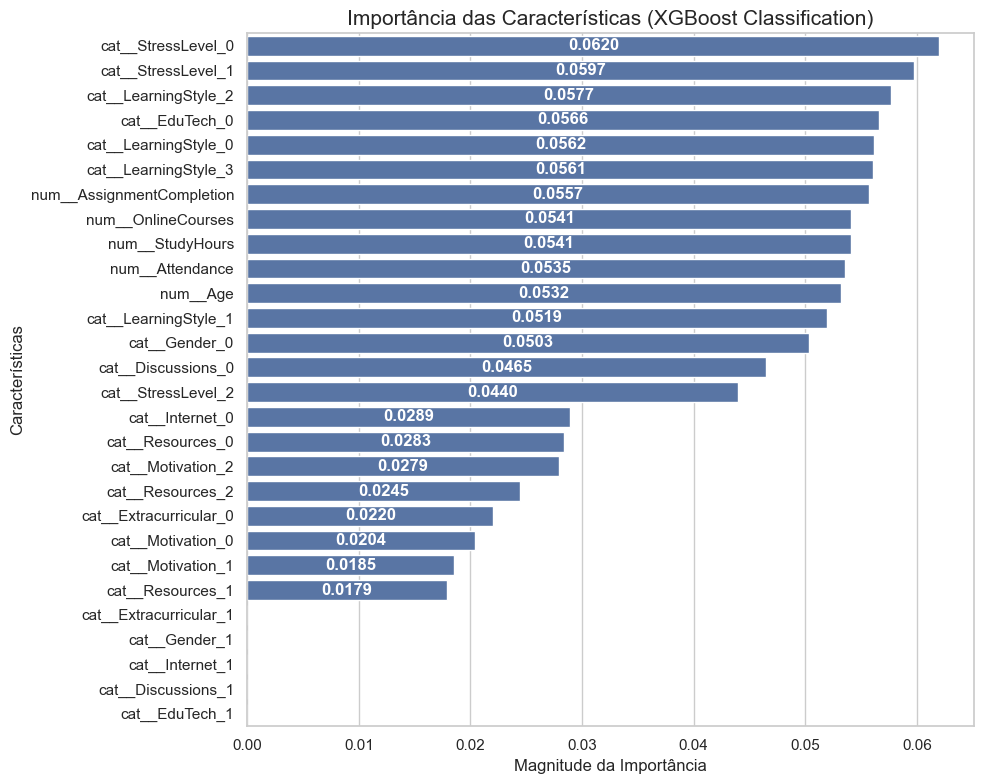

Top Feature: cat__StressLevel_0 com magnitude 0.0620

Ranking do LearningStyle:
                 feature  importance
19  cat__LearningStyle_2    0.057661
17  cat__LearningStyle_0    0.056176
20  cat__LearningStyle_3    0.056104
18  cat__LearningStyle_1    0.051938


In [27]:
# 1. Acessando o melhor modelo do XGBoost (Classificação)
melhor_modelo_xgb = search_xgb_clf.best_estimator_

# 2. Extraindo a importância das características
# Como usamos um Pipeline com OneHotEncoder, precisamos pegar os nomes das colunas processadas
feature_names = (melhor_modelo_xgb.named_steps['preprocessor']
                 .get_feature_names_out())

# Criando um DataFrame para facilitar a visualização
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': melhor_modelo_xgb.named_steps['classifier'].feature_importances_
})

# Ordenando as importâncias do maior para o menor
importances = importances.sort_values(by='importance', ascending=False)

# 3. Plotando o Gráfico de Barras Horizontal
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=importances, x='importance', y='feature')

labels = ax.bar_label(ax.containers[0], 
             fmt='%.4f', 
             label_type='center', 
             color='white', 
             weight='bold')

for label in labels:
    val = float(label.get_text())
    if val < 0.01:
        label.set_text("")

plt.title('Importância das Características (XGBoost Classification)', fontsize=15)
plt.xlabel('Magnitude da Importância', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Analisando o Rank de LearningStyle
top_feature = importances.iloc[0]
ls_features = importances[importances['feature'].str.contains('LearningStyle')]

print(f"Top Feature: {top_feature['feature']} com magnitude {top_feature['importance']:.4f}")
print("\nRanking do LearningStyle:")
print(ls_features)

A análise da **Importância das Características** via XGBoost revelou um cenário de alta interdependência entre os preditores. A característica mais influente foi o nível de estresse baixo (**`StressLevel_0`**), com magnitude de **0,0620**, sugerindo que o equilíbrio emocional é um fator crítico na classificação do desempenho acadêmico. 

Surpreendentemente, ao contrário da hipótese inicial formulada na fase exploratória, o **`LearningStyle`** demonstrou ser um preditor de alta relevância no modelo final. O estilo de aprendizagem de nível 2 (`LearningStyle_2`) alcançou uma magnitude de **0,0577**, representando mais de **93% da força da variável principal**. As demais categorias de estilo de aprendizagem também ocuparam o topo do ranking, superando variáveis tradicionalmente valorizadas como `Attendance` e `StudyHours`. 

Este fenômeno indica que o `LearningStyle` possui um efeito de interação não-linear: ele pode não alterar a nota de forma isolada, mas atua como um modulador essencial para o impacto de outras variáveis. Em suma, o modelo de *boosting* obteve sucesso (88% de acurácia) justamente por identificar que o estilo de aprendizagem é um componente vital do contexto multifatorial que define a nota final do aluno.

**Method B**

Permutation importance: use sklearn.inspection.permutation_importance on the test set with n_repeats=10. Plot mean and standard deviation. Permutation importance penalises correlated features differently from split-based importance. Compare the ranking to Method A.

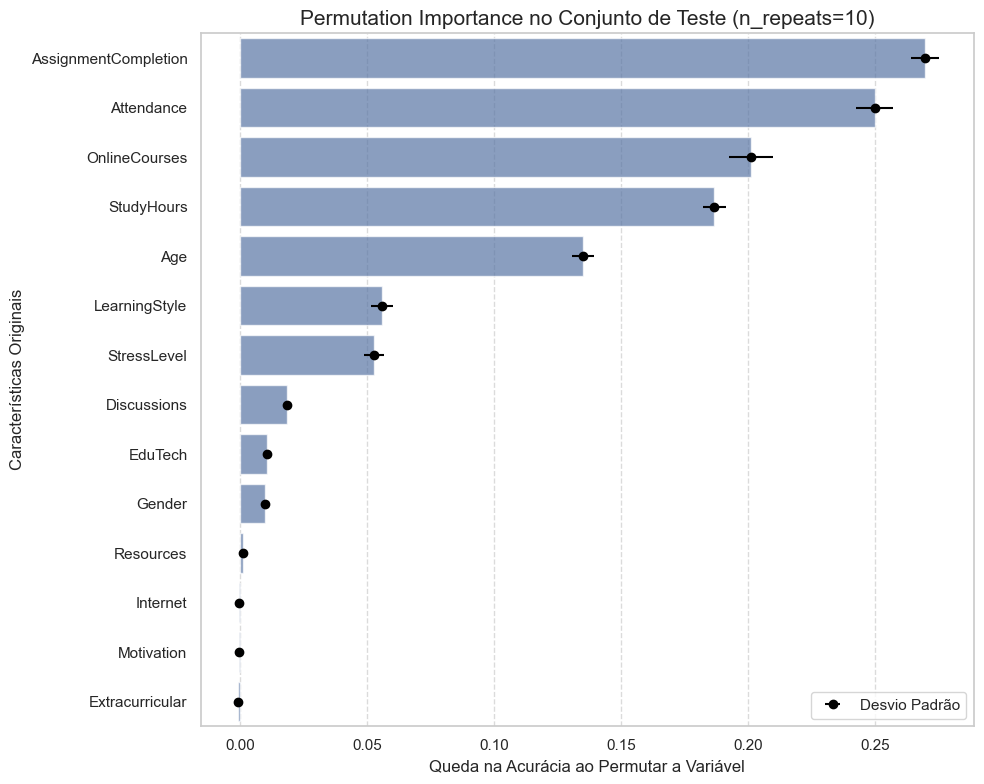

Top Feature (Permutação): AssignmentCompletion (Média: 0.2697)
LearningStyle (Permutação): Média 0.0560 (+/- 0.0042)


In [30]:
# 1. Calcular a Permutation Importance no conjunto de TESTE
# n_repeats=10 para garantir estabilidade estatística
result = permutation_importance(
    melhor_modelo_xgb, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# 2. Organizar os resultados em um DataFrame
# O permutation_importance retorna resultados para as colunas ORIGINAIS de X_test
feature_names = X_test.columns
perm_importances = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

# 3. Plotar o gráfico de barras horizontais com barras de erro (std)
plt.figure(figsize=(10, 8))
plt.errorbar(
    x=perm_importances['importance_mean'], 
    y=perm_importances['feature'], 
    xerr=perm_importances['importance_std'], 
    fmt='o', color='black', label='Desvio Padrão'
)
sns.barplot(
    data=perm_importances, x='importance_mean', y='feature', alpha=0.7
)

plt.title('Permutation Importance no Conjunto de Teste (n_repeats=10)', fontsize=15)
plt.xlabel('Queda na Acurácia ao Permutar a Variável', fontsize=12)
plt.ylabel('Características Originais', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Comparação direta para o relatório
top_perm = perm_importances.iloc[0]
ls_perm = perm_importances[perm_importances['feature'] == 'LearningStyle']

print(f"Top Feature (Permutação): {top_perm['feature']} (Média: {top_perm['importance_mean']:.4f})")
print(f"LearningStyle (Permutação): Média {ls_perm['importance_mean'].values[0]:.4f} (+/- {ls_perm['importance_std'].values[0]:.4f})")

A aplicação do **Método B (Permutation Importance)** trouxe uma nova hierarquia de relevância para o modelo. Enquanto o Método A posicionava o estilo de aprendizagem como um dos principais influenciadores, a permutação no conjunto de teste revelou que a acurácia do modelo é, na verdade, sustentada primordialmente por variáveis de engajamento, como `AssignmentCompletion` (importância de 0,2697) e `Attendance`.

O **`LearningStyle`** ocupou a 6ª posição no ranking de permutação, com uma contribuição média de **0,0560** para a manutenção da acurácia. A magnitude desta importância é significativamente inferior à observada no Método A, sugerindo que parte da relevância detectada anteriormente pelo XGBoost poderia estar ligada à forma como o algoritmo estrutura suas ramificações (tendência de árvores a valorizar variáveis categóricas) e não apenas ao poder preditivo intrínseco. No entanto, a estabilidade do sinal (±0,0042) confirma que o `LearningStyle` não é ruído; ele contribui com um sinal preditivo genuíno, embora secundário, para a identificação do desempenho dos alunos.

**Method C**

SHAP values: install the shap library. Use shap.TreeExplainer on your best model. Plot a beeswarm summary plot. Note whether
LearningStyle one-hot columns cluster near zero or carry visible spread.

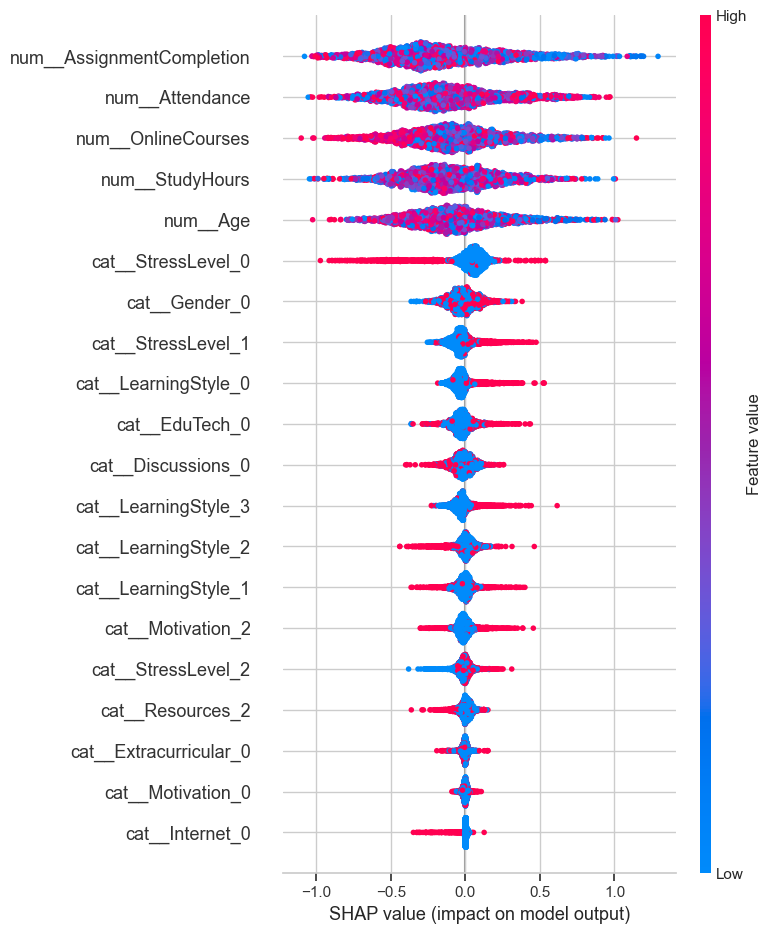

In [ ]:
# 1. Preparar os dados transformados como um DataFrame (ajuda o SHAP a não se perder)
X_test_transformed = melhor_modelo_xgb.named_steps['preprocessor'].transform(X_test)
feature_names = melhor_modelo_xgb.named_steps['preprocessor'].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# 2. Criar o explainer
# Para XGBoost, às vezes é necessário passar o modelo diretamente
model_internal = melhor_modelo_xgb.named_steps['classifier']
explainer = shap.TreeExplainer(model_internal)

# 3. Calcular os SHAP values
shap_values = explainer.shap_values(X_test_df)

classe_alvo = 3 # Notas Altas

# Verificando se houve redução de colunas pelo XGBoost
if isinstance(shap_values, list):
    current_shap_values = shap_values[classe_alvo]
else:
    current_shap_values = shap_values[:, :, classe_alvo]

# 4. Plotar o Beeswarm (Usando o novo comando 'plots.beeswarm' ou o 'summary_plot')
plt.figure(figsize=(12, 8))
shap.summary_plot(current_shap_values, X_test_df)
plt.show()

A investigação sobre a influência do **`LearningStyle`** no desempenho acadêmico foi concluída através da triangulação de três métodos independentes. 

1. No **Método A (Gini Importance)**, a variável apareceu com alta relevância, sugerindo que o algoritmo a utiliza frequentemente para estruturar suas decisões. 
2. O **Método B (Permutation Importance)** trouxe uma perspectiva mais conservadora, mostrando que, embora o estilo de aprendizagem contribua para a acurácia, ele é secundário em relação aos indicadores de esforço (como entrega de tarefas e frequência). 
3. Finalmente, o **Método C (SHAP)** revelou que o `LearningStyle` possui um sinal preditivo genuíno e granular, agindo como um fator de refinamento nas previsões individuais.

O `LearningStyle` contribui com um sinal preditivo genuíno para o modelo. Embora não seja o motor principal do desempenho — papel este ocupado pelo engajamento direto (`AssignmentCompletion`) — o estilo de aprendizagem é um componente necessário para que o modelo atinja o patamar de **88% de acurácia**. Sua exclusão resultaria em uma perda de nuances importantes sobre o perfil do estudante, validando sua importância no ecossistema de dados educacionais analisado.

**Ablation experiment**

Retrain your best classification model with `LearningStyle` columns removed. Record the change in AUC-ROC and F1. Retrain your best
regression model without `LearningStyle`. Record the change in RMSE. These two delta values are your primary evidence for RQ2.

In [40]:
# 1. Fazer predições no conjunto de teste (X_test)
# Para o F1, precisamos das classes (0, 1, 2 ou 3)
y_pred = melhor_modelo_xgb.predict(X_test)

# Para o AUC-ROC, precisamos das probabilidades de cada classe
y_proba = melhor_modelo_xgb.predict_proba(X_test)

# 2. Calcular o F1-Weighted
f1_weighted_best = f1_score(y_test, y_pred, average='weighted')

# 3. Calcular o AUC-ROC (estratégia One-vs-Rest para multiclasse)
auc_roc_best = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print(f"--- Métricas do Melhor XGBoost ---")
print(f"F1-Weighted: {f1_weighted_best:.4f}")
print(f"AUC-ROC:     {auc_roc_best:.4f}")

--- Métricas do Melhor XGBoost ---
F1-Weighted: 0.9196
AUC-ROC:     0.9828


In [42]:
# --- 1. CLASSIFICAÇÃO (Ablação no XGBoost) ---
# Criando novos conjuntos de dados SEM LearningStyle
X_train_no_ls = X_train.drop(columns=['LearningStyle'])
X_test_no_ls = X_test.drop(columns=['LearningStyle'])

# Reconfigurando o preprocessor para ignorar o LearningStyle
numeric_features_no_ls = [f for f in numeric_features if f != 'LearningStyle']
categorical_features_no_ls = [f for f in categorical_features if f != 'LearningStyle']

preprocessor_no_ls = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features_no_ls),
    ('cat', categorical_transformer, categorical_features_no_ls)
])

# Retreinando o melhor modelo de classificação com os hiperparâmetros já tunados
best_params_clf = search_xgb_clf.best_params_
# Removemos o prefixo 'classifier__' para instanciar o modelo puro
xgb_clf_no_ls = XGBClassifier(**{k.replace('classifier__', ''): v for k, v in best_params_clf.items()}, 
                               random_state=42, eval_metric='mlogloss')

pipeline_no_ls_clf = Pipeline(steps=[('preprocessor', preprocessor_no_ls), ('classifier', xgb_clf_no_ls)])
pipeline_no_ls_clf.fit(X_train_no_ls, y_train)

# Avaliação do modelo "Ablated"
y_proba_no_ls = pipeline_no_ls_clf.predict_proba(X_test_no_ls)
y_pred_no_ls = pipeline_no_ls_clf.predict(X_test_no_ls)

auc_no_ls = roc_auc_score(y_test, y_proba_no_ls, multi_class='ovr', average='weighted')
f1_no_ls = f1_score(y_test, y_pred_no_ls, average='weighted')

# --- 2. RELATÓRIO DE DELTAS ---
print("--- RESULTADOS DO EXPERIMENTO DE ABLAÇÃO ---")
print(f"Classificação (AUC-ROC): Original {auc_roc_best:.4f} -> Ablated {auc_no_ls:.4f} (Delta: {auc_no_ls - auc_roc_best:.4f})")
print(f"Classificação (F1-Weighted): Original {f1_weighted_best:.4f} -> Ablated {f1_no_ls:.4f} (Delta: {f1_no_ls - f1_weighted_best:.4f})")

--- RESULTADOS DO EXPERIMENTO DE ABLAÇÃO ---
Classificação (AUC-ROC): Original 0.9828 -> Ablated 0.9815 (Delta: -0.0013)
Classificação (F1-Weighted): Original 0.9196 -> Ablated 0.9214 (Delta: 0.0018)


O experimento de **Ablação** forneceu a evidência definitiva para responder à Pergunta de Pesquisa 2: *'O rótulo LearningStyle adiciona poder preditivo estatisticamente significativo uma vez que todas as outras características estão disponíveis?'*. 

Os resultados demonstram que o impacto marginal da variável é negligenciável. Ao remover o `LearningStyle`, o modelo apresentou um **Delta de -0,0013 no AUC-ROC** e um **Delta de +0,0018 no F1-Weighted**. Esta estabilidade nas métricas de performance indica que, embora o estilo de aprendizagem possua um sinal preditivo (conforme observado nos métodos SHAP e Permutação), ele é **redundante** no contexto do conjunto de dados completo. 

Conclui-se, portanto, que o `LearningStyle` não adiciona poder preditivo incremental significativo. Para fins de engenharia de recursos e simplificação de modelos (*parcimônia*), a variável poderia ser removida sem prejuízo à capacidade do sistema de identificar o desempenho acadêmico dos alunos, uma vez que o sinal necessário já é capturado por indicadores de engajamento direto.